In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ic272_lab4_rent.csv")

In [3]:
df.head(3)

,area,rooms,age,dist_km,floors,rent
0,6.95,1.0,2.07,3.37,3.0,49.43
1,6.60,1.0,4.16,2.75,3.0,49.77
2,7.94,3.0,1.55,1.50,3.0,67.01


In [4]:
df.shape

(300, 6)

In [5]:
for col in df.columns:
    print(f"{col} : min = {df[col].min()} , max = {df[col].max()}")

area : min = 5.05 , max = 9.5
rooms : min = 1.0 , max = 5.0
age : min = 0.0 , max = 7.95
dist_km : min = 1.02 , max = 8.91
floors : min = 1.0 , max = 3.0
rent : min = 29.55 , max = 85.94


In [6]:
def train_test_split(X,y,test_size,seed):

    n = len(X)

    #create random generator
    rng = np.random.default_rng(seed)

    # shuffle indices 
    indices = rng.permutation(n)

    # number of test samples
    n_test = int(n*test_size)

    # First shuffle indices 
    test_indices = indices[:n_test]

    # remaining indices = training set
    train_indices = indices[n_test:]

    X_train = X[train_indices]
    X_test = X[test_indices]

    y_train = y[train_indices]
    y_test = y[test_indices]

    return X_train,X_test,y_train,y_test

In [9]:
feature_cols = [
    "area" , "rooms" , "age" , "dist_km" , "floors"
]

X = df[feature_cols].to_numpy()
y = df["rent"].to_numpy()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, seed=42
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples : {len(X_test)}")

Training samples : 240
Testing samples : 60


In [13]:
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape : {X_test.shape}")

X_train shape : (240, 5)
X_test shape : (60, 5)


In [14]:
def fit_simple_lr(x,y):

    # mean of x
    x_mean = np.mean(x)

    # mean of y 
    y_mean = np.mean(y)

    # numerator
    numerator = np.sum(
        (x-x_mean)*(y-y_mean)
    )

    # denominator
    denominator = np.sum(
        (x - x_mean)**2
    )

    # calculate slope
    w = numerator/denominator

    # calculate intercept
    b = y_mean - w*x_mean

    return w,b

In [15]:
# area => feature
x_train_area = X_train[:,0]

w,b = fit_simple_lr(
    x_train_area,y_train
)

print(f"w = {round(w,3)}")
print(f"b = {round(b,3)}")

w = 5.8
b = 12.08


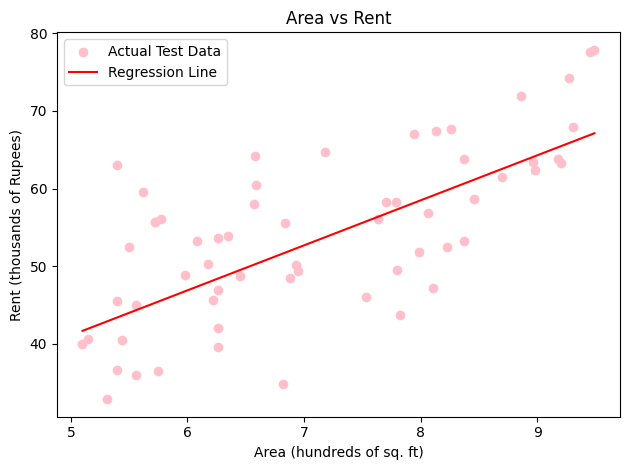

In [20]:
# extract area from test set
x_test_area = X_test[:,0]

# predictions
y_pred_simple = w*x_test_area + b

# scatter plot
plt.scatter(
    x_test_area,
    y_test,
    label = "Actual Test Data",
    color = 'pink'
)

# Sort values for clean line
sorted_indices = np.argsort(x_test_area)

plt.plot(
    x_test_area[sorted_indices],
    y_pred_simple[sorted_indices],
    label = "Regression Line",
    color = 'red'
)

plt.xlabel("Area (hundreds of sq. ft)")
plt.ylabel("Rent (thousands of Rupees)")

plt.title("Area vs Rent")
plt.legend()
plt.tight_layout()

plt.show()

In [21]:
def design_matrix(X):

    n = X.shape[0]

    # cols of ones
    ones = np.ones((n,1))

    # Add ones as first column

    A = np.concatenate(
        (ones,X),
        axis = 1
    )

    return A

In [22]:
A_train = design_matrix(X_train)

print(f"original X shape : {X_train.shape}")
print(f"Design Matrix shape : {A_train.shape}")

original X shape : (240, 5)
Design Matrix shape : (240, 6)


In [23]:
def fit_normal_equation(X,y):

    # create design matrix 
    A = design_matrix(X)

    # left side 
    left = A.T@A

    # right side 
    right = A.T@y

    # solve
    # (A^TA) theta = A^TY

    # we use np.linalg.solve instead of 
    # explicitly computing the inverse because 
    # solving a linear system is generally more
    # numerically stable and efficient

    theta = np.linalg.solve(
        left,right
    )
    return theta

In [25]:
theta_normal = fit_normal_equation(
    X_train,y_train
)

names = [
    "intercept" , "area" , "rooms" , "age" , "dist_km" , "floors"
]

print("Normal Equation Coefficients")

for name, value in zip(names,theta_normal):
    print(f"{name:10s} : {value:.3f}")

Normal Equation Coefficients
intercept  : 12.083
area       : 6.071
rooms      : 3.131
age        : -1.343
dist_km    : -1.938
floors     : 1.830


In [32]:
def fit_gradient_descent(X,y,lr,n_iters):

    # Design matrix 
    A = design_matrix(X)

    n = len(y)

    # start from theta = 0
    theta = np.zeros(A.shape[1])

    # store losses
    losses = []

    for i in range(n_iters):

        # predictions
        y_pred = A@theta

        # error
        error = y_pred - y

        # loss
        loss = np.mean(error**2)
        losses.append(loss)

        # gradient

        gradient = (2/n)* (A.T@error)

        # update theta
        theta = theta - lr*gradient

    return theta , losses

In [33]:
theta_gd , losses = fit_gradient_descent(
    X_train , y_train , lr = 0.005 , n_iters = 20000
)

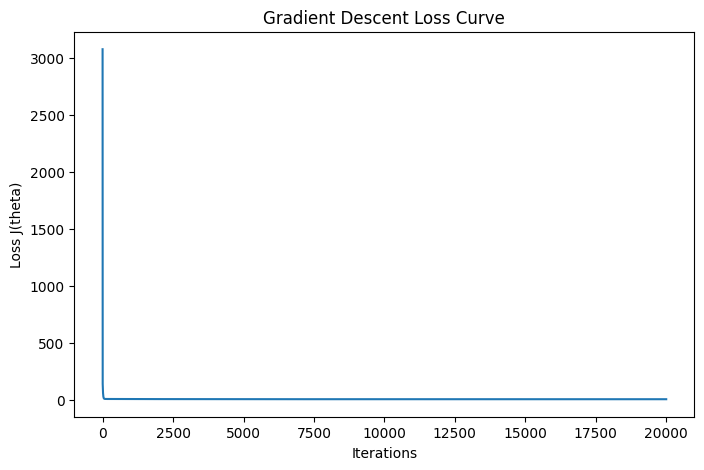

In [34]:
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel("Iterations")
plt.ylabel("Loss J(theta)")

plt.title("Gradient Descent Loss Curve")

plt.show()

In [35]:
print(f"Normal Equation Theta")

for name,value in zip(names,theta_normal):

    print(f"{name:10s} : { value:.3f}")

Normal Equation Theta
intercept  : 12.083
area       : 6.071
rooms      : 3.131
age        : -1.343
dist_km    : -1.938
floors     : 1.830


In [36]:
print(f"Gradient Descent Theta")

for name,value in zip(names,theta_gd):

    print(f"{name:10s} : { value:.3f}")

Gradient Descent Theta
intercept  : 11.733
area       : 6.100
rooms      : 3.141
age        : -1.339
dist_km    : -1.931
floors     : 1.854


In [39]:
max_diff = np.max(
    np.abs(theta_gd - theta_normal)
)
print(f"Largest absolute differnece: {max_diff:.4f}")

Largest absolute differnece: 0.3504


C:\Users\ohhaa\AppData\Local\Temp\ipykernel_7816\4091431383.py:23: RuntimeWarning: overflow encountered in square
  loss = np.mean(error**2)
C:\Users\ohhaa\AppData\Local\Temp\ipykernel_7816\4091431383.py:28: RuntimeWarning: overflow encountered in matmul
  gradient = (2/n)* (A.T@error)
C:\Users\ohhaa\AppData\Local\Temp\ipykernel_7816\4091431383.py:31: RuntimeWarning: invalid value encountered in subtract
  theta = theta - lr*gradient


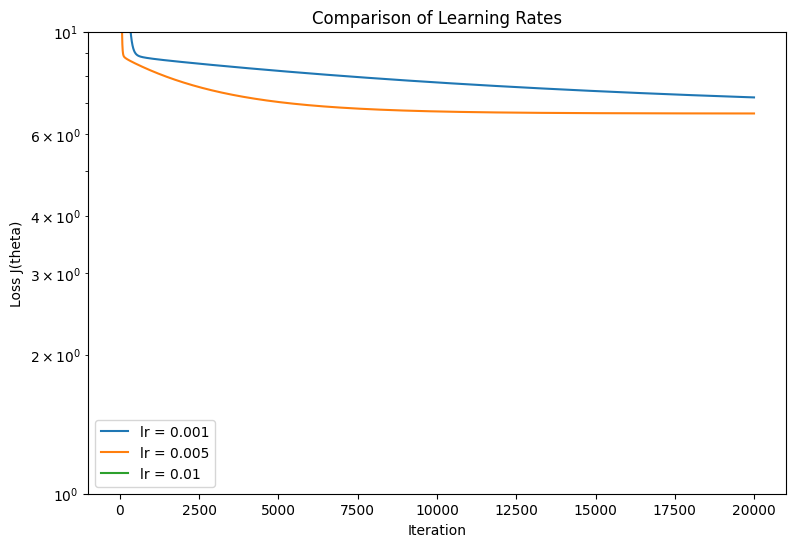

In [41]:
learning_rates = [
    0.001,
    0.005,
    0.01
]

plt.figure(figsize=(9, 6))


for lr in learning_rates:

    theta_temp, losses_temp = fit_gradient_descent(
        X_train,
        y_train,
        lr=lr,
        n_iters=20000
    )

    plt.plot(
        losses_temp,
        label=f"lr = {lr}"
    )


plt.yscale("log")

plt.xlabel("Iteration")
plt.ylabel("Loss J(theta)")

plt.title("Comparison of Learning Rates")

plt.legend()

plt.show()

In [42]:
A_test = design_matrix(X_test)
A_train = design_matrix(X_train)

y_pred_test = A_test@theta_gd
y_pred_train = A_train@theta_gd

In [43]:
def rmse(y_true,y_pred):

    squared_errors = (
        y_true - y_pred
    )**2

    mean_squared_error = np.mean(squared_errors)

    return np.sqrt(mean_squared_error)

In [48]:
def r2_score(y_true,y_pred):

    ss_res = np.sum((y_true-y_pred)**2)

    ss_tot = np.sum((y_true - np.mean(y_true))**2)

    return 1 - (ss_res/ss_tot)

In [45]:
# RMSE
test_rmse = rmse(
    y_test,y_pred_test
)

train_rmse = rmse(
    y_train, y_pred_train
)

In [49]:
# R2

test_r2 = r2_score(
    y_test,y_pred_test
)

train_r2 = r2_score(
    y_train , y_pred_train
)

In [50]:
print("Test RMSE:", f"{test_rmse:.4f}")
print("Test R2:", f"{test_r2:.4f}")

print()

print("Train RMSE:", f"{train_rmse:.4f}")
print("Train R2:", f"{train_r2:.4f}")

Test RMSE: 2.4868
Test R2: 0.9460

Train RMSE: 2.5795
Train R2: 0.9409


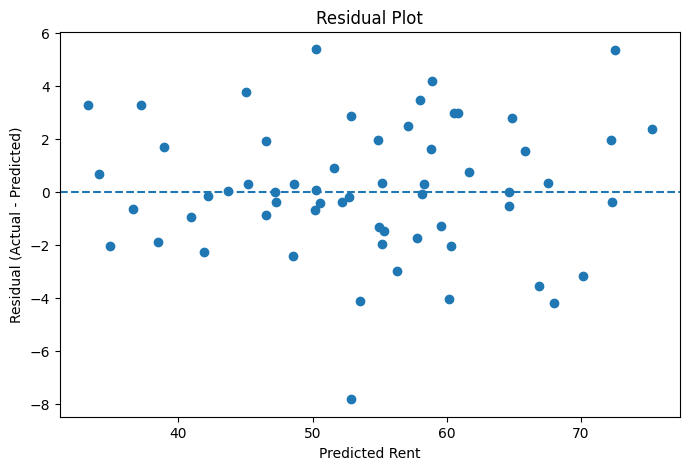

In [51]:
residual = (y_test-y_pred_test)

plt.figure(figsize=(8,5))

plt.scatter(y_pred_test, residual)

plt.axhline(y=0 , linestyle = "--")

plt.xlabel("Predicted Rent")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")

plt.show()